# Access and Visualization of MASTER L1B Radiance Data

## Overview

The MODIS/ASTER Airborne Simulator ([MASTER](https://masterprojects.jpl.nasa.gov/)) is a multispectral scanning spectrometer that collects calibrated radiance across 50 spectral channels spanning 0.46 to 12.879 micrometers — covering the visible, near-infrared, shortwave infrared, and thermal infrared portions of the electromagnetic spectrum. MASTER has flown since 1998 on a variety of NASA aircraft as a Facility Instrument of the [NASA Airborne Science Program](https://airbornescience.nasa.gov/).

In this tutorial we use [`earthaccess`](https://earthaccess.readthedocs.io/) to discover and access MASTER Level 1B (L1B) calibrated radiance data from the **Western Diversity Time Series (WDTS) Spring 2024** campaign. The WDTS campaign observes California's ecosystems and supports monitoring of natural hazards such as wildfires, volcanoes, and drought.

MASTER L1B files are georeferenced multispectral images in **HDF-4** format, archived as individual flight-line granules at the ORNL DAAC.

### Datasets Used

| Dataset | DOI | Concept ID |
|---|---|---|
| MASTER: Western Diversity Time Series Campaign, WDTS, Spring 2024 | [10.3334/ORNLDAAC/2383](https://doi.org/10.3334/ORNLDAAC/2383) | C3323041261-ORNL_CLOUD |

### Learning Objectives

- Search NASA CMR for a MASTER campaign collection by short name
- List and filter granules by spatial bounding box and date range using `earthaccess`
- Download a HDF-4 L1B granule and explore its file structure and extract a radiance band
- Visualize a selected MASTER radiance band
  
### Prerequisites

A free [NASA Earthdata Login](https://urs.earthdata.nasa.gov/) account is required. See the [prerequisites](../../docs/prerequisites.md) page for setup instructions.

## Import Libraries

In [1]:
import earthaccess
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import pandas as pd
import pyhdf.SD as SD
import xarray
import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt
import warnings
warnings.filterwarnings('ignore')

xyz = "https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}"
attr = "ESRI"

## Authentication

Use `earthaccess.login()` to authenticate with your NASA Earthdata Login credentials. If you have a `.netrc` file configured, login will complete without a prompt.

In [2]:
auth = earthaccess.login()

## Search for the MASTER WDTS Collection

Each MASTER campaign is archived as its own collection at the ORNL DAAC. We search by `instrument` and `project` to locate the Western Diversity Time Series (WDTS) L1B MASTER datasets.

In [3]:
# Search for the MASTER WDTS collections
collections = earthaccess.search_datasets(
    instrument="MASTER", # 
    project = "WDTS"
)

print(f"Collections found: {len(collections)}")
for c in collections:
    print(f"  Title    : {c.get_umm('EntryTitle')}")
    print(f"  ShortName: {c.get_umm('ShortName')}")

Collections found: 9
  Title    : MASTER: Flight Line Geospatial Polygons and Contextual Data
  ShortName: MASTER_Flightline_Locator_2151
  Title    : MASTER: Image Overlays for Level 2 Emissivity and Land Surface Temperature
  ShortName: MASTER_L2_Emiss_LST_Overlays_2487
  Title    : MASTER: Quicklook Images for Level 2 Emissivity and Land Surface Temperature
  ShortName: MASTER_L2_Emiss_LST_Quicklooks_2488
  Title    : MASTER: Western Diversity Time Series Campaign, WDTS, September 2022
  ShortName: MASTER_WDTS_Fall_2022_2141
  Title    : MASTER: Western Diversity Time Series Campaign, WDTS, California, USA, Fall 2020
  ShortName: MASTER_WDTS_SeptOct_2020_1940
  Title    : MASTER: Western Diversity Time Series Campaign, WDTS, California, USA, Spring 2021
  ShortName: MASTER_WDTS_Spring_2021_1953
  Title    : MASTER: Western Diversity Time Series Campaign, WDTS, Spring 2023
  ShortName: MASTER_WDTS_Spring_2023_2252
  Title    : MASTER: Western Diversity Time Series Campaign, WDTS, Spr

## Search for Granules

We search for L1B flight-line granules from the WDTS 2024 campaign with ShortName as `MASTER_WDTS_Spring_2024_2383`. MASTER L1B granules are individual flight-line files covering a swath width of roughly 6–37 km depending on flight altitude.

Here, we search across the full campaign date range and filter by a bounding box over California.

In [4]:
# Bounding box: (west, south, east, north) — California/Nevada region
bbox = (-123.75, 31.95, -112.5, 40.98)

# Search granules from MASTER WDTS Spring 2024 L1B Collection
granules = earthaccess.search_data(
    short_name='MASTER_WDTS_Spring_2024_2383',
    bounding_box=bbox,
    temporal=('2024-06-04', '2024-06-28'),
)

print(f"Granules found: {len(granules)}")

Granules found: 336


## Inspect Granule Metadata

We inspect the CMR granule metadata to identify file names and types before accessing any data.

In [5]:
# Build a DataFrame from granule metadata, first 25 granules
rows = [{'producer_granule_id': g['umm'].get('GranuleUR', '')} for g in granules[:25]]
df_granules = pd.DataFrame(rows)
print(df_granules[['producer_granule_id']].to_string(index=False))

                                                                  producer_granule_id
                           MASTER_WDTS_Spring_2024.MASTER_2495500_20240604_config.txt
          MASTER_WDTS_Spring_2024.MASTER_2495500_20240604_spectral_response_table.zip
              MASTER_WDTS_Spring_2024.MASTERL1B_2495500_01_20240604_1743_1757_V01.jpg
                        MASTER_WDTS_Spring_2024.MASTER_2495500_20240604_ancillary.txt
                          MASTER_WDTS_Spring_2024.MASTER_2495500_20240604_summary.txt
               MASTER_WDTS_Spring_2024.MASTER_2495500_20240604_spectral_band_info.txt
              MASTER_WDTS_Spring_2024.MASTERL1B_2495500_01_20240604_1743_1757_V01.hdf
                       MASTER_WDTS_Spring_2024.MASTER_2495500_20240604_flightpath.gif
         MASTER_WDTS_Spring_2024.MASTERL2_2495500_01_20240604_1743_1757_V01-QAmap.zip
MASTER_WDTS_Spring_2024.MASTERL2_2495500_01_20240604_1743_1757_V01-emissivity_tes.zip
      MASTER_WDTS_Spring_2024.MASTERL2_2495500_01_2024

As we see above, MASTER L1B dataset has different file types. Please refer to the [user guide](https://data.ornldaac.earthdata.nasa.gov/public/master/MASTER_WDTS_Spring_2024/comp/MASTER_WDTS_Spring_2024.pdf) for more information about the data files.

## Map Flight Lines

We extract the footprint polygon from each granule's spatial bounds and plot the flight lines over the region of interest.

In [6]:
# plot granule footprints over the study area
flight_paths_gdf = gpd.GeoDataFrame(granules, geometry=gpd.GeoSeries(granules, crs=4326))
flight_paths_gdf.geometry.explore(
    tiles=xyz, attr=attr, color="red",
    style_kwds={"weight": 2, "fillOpacity": 0.1},
    name="L1 Radiance Footprints",
)

## Access an L1B Granule

MASTER L1B files are in **HDF-4** format. We open the first granule directly from the Earthdata Cloud using `earthaccess.open()` which returns file-like objects that can be read without downloading to disk.

Because `pyhdf` requires a local file path, we download a granule using `earthaccess`.

In [7]:
# filter HDF granules only
g_hdfs = [g for g in granules if g.data_links()[0].endswith(".hdf")]

# Download the first granule from the cloud
downloaded = earthaccess.download(g_hdfs[0], local_path='data')
print(f"Granule download: {downloaded[0].as_posix()}")

QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

Granule download: data/MASTERL1B_2495500_01_20240604_1743_1757_V01.hdf


## Explore the HDF-4 File Structure

MASTER L1B HDF-4 files contain scientific datasets (SDSs) for each of the 50 spectral bands along with geolocation arrays. We list all available SDSs to understand the file layout. Please refer to the [user guide](https://data.ornldaac.earthdata.nasa.gov/public/master/MASTER_WDTS_Spring_2024/comp/MASTER_WDTS_Spring_2024.pdf) for more information about the SDSs.


In [8]:
# Open the HDF-4 file
hdf = SD.SD(downloaded[0].as_posix(), SD.SDC.READ)

# list all Scientific Dataset (SDS) names and shapes
datasets = hdf.datasets()
print(f"{'SDS Name':<40}  {'Shape':>20}  {'Type':>8}")
print('-' * 75)
for name, (dims, shape_info, dtype, idx) in datasets.items():
    print(f"{name:<40}  {str(shape_info):>20}  {str(dtype):>8}")

SDS Name                                                 Shape      Type
---------------------------------------------------------------------------
Left50%ResponseWavelength                                (50,)         5
Central100%ResponseWavelength                            (50,)         5
Right50%ResponseWavelength                               (50,)         5
EffectiveCentralWavelength_IR_bands                      (50,)         5
TemperatureCorrectionSlope                               (50,)         5
TemperatureCorrectionIntercept                           (50,)         5
SolarSpectralIrradiance                                  (50,)         5
DataSetHeader                                        (149, 97)         4
ScanLineCounter                                        (5126,)        24
GreenwichMeanTime                                      (5126,)        24
YearMonthDay                                           (5126,)        24
AircraftRollCount                               

## Read Radiance Bands

MASTER L1B data contains 50 calibrated radiance bands spanning visible through thermal infrared. Bands 1–25 cover the reflective solar spectrum; bands 26–50 cover the thermal infrared. We read several bands and inspect their statistics.

In [9]:
radiance_sds = 'CalibratedData'  # radiance SDS names
sds = hdf.select(radiance_sds)
radiance_shape = sds.dimensions()
print(f"Radiance SDS '{radiance_sds}' with dimensions: {sds.info()[2]}")

radiance = sds[:].astype(np.float32)
attrs = sds.attributes()
scale = attrs.get('scale_factor', 1.0)
fill  = attrs.get('_FillValue', -9999)
units = attrs.get('units', None)

# Apply scale factor and fill value 
radiance = np.where(radiance == fill, np.nan,
                    radiance * np.array(scale)[:, np.newaxis])

print(f"Radiance array shape: {radiance.shape}")
print(f"  scan lines × channels × pixels")
print(f"Min (non-nan): {np.nanmin(radiance):.4f} {units}")
print(f"Max (non-nan): {np.nanmax(radiance):.4f} {units}")

Radiance SDS 'CalibratedData' with dimensions: [5126, 50, 716]
Radiance array shape: (5126, 50, 716)
  scan lines × channels × pixels
Min (non-nan): -1.9200 watts/meter2/steradian/micron
Max (non-nan): 498.1000 watts/meter2/steradian/micron


## Read Geolocation and Spectral Range

The latitude and longitude arrays in MASTER L1B files provide per-pixel geolocation for each scan line and sample. We read these to support georeferenced visualization.

In [10]:
# Read latitude and longitude arrays
lat_sds_name = 'PixelLatitude'
lon_sds_name = 'PixelLongitude'
# center wavelengths 
wv_sds_name = 'Central100%ResponseWavelength'

lat = hdf.select(lat_sds_name)[:].astype(np.float32)
lon = hdf.select(lon_sds_name)[:].astype(np.float32)
wv = hdf.select(wv_sds_name)[:].astype(np.float32)
    
# Mask fill values (typically -999 or 0 outside swath)
lat = np.where(lat < -90, np.nan, lat)
lon = np.where(lon < -180, np.nan, lon)
    
print(f"Lat range: {np.nanmin(lat):.4f} to {np.nanmax(lat):.4f}")
print(f"Lon range: {np.nanmin(lon):.4f} to {np.nanmax(lon):.4f}")
print(f"Spectral range: {np.nanmin(wv):.4f} to {np.nanmax(wv):.4f}")

Lat range: 36.6319 to 38.1581
Lon range: -119.1226 to -118.6993
Spectral range: 0.4620 to 12.8500


## Band Statistics Summary

We compute per-band statistics across all 50 channels to understand the radiance range and identify any bands with fill data. Bands 1-25 are in visible–shortwave infrared (SWIR) region and bands 26–50 are in thermal infrared (TIR) region.

In [11]:
n_bands = wv.shape[0]
stats = []
for b in range(n_bands):
    band_data = radiance[:,b,:]
    valid = band_data[~np.isnan(band_data)]
    stats.append({
        'band': b + 1,
        'min': np.nanmin(band_data) if len(valid) > 0 else np.nan,
        'max': np.nanmax(band_data) if len(valid) > 0 else np.nan,
        'mean': np.nanmean(band_data) if len(valid) > 0 else np.nan,
        'valid_pct': 100 * len(valid) / band_data.size
    })

df_stats = pd.DataFrame(stats)
print(df_stats.to_string(index=False, float_format='{:.3f}'.format))

 band    min     max   mean  valid_pct
    1 32.300 498.100 89.641    100.000
    2 24.100 493.400 82.208    100.000
    3 18.200 495.400 81.628    100.000
    4 13.500 456.100 74.555    100.000
    5  8.300 388.100 64.248    100.000
    6  7.500 338.500 66.012    100.000
    7  5.400 280.300 69.473    100.000
    8  4.800 249.700 69.358    100.000
    9  3.500 194.000 59.810    100.000
   10  3.000 146.200 46.744    100.000
   11  2.500  93.500 28.968    100.000
   12  0.504  48.024 11.607    100.000
   13  0.450  43.530 11.070    100.000
   14  0.450  37.365  9.291    100.000
   15  0.300  25.440  6.188    100.000
   16  0.200   5.720  1.199    100.000
   17  0.010   1.520  0.305    100.000
   18  0.080   2.970  0.437    100.000
   19  0.040   9.180  1.821    100.000
   20  0.030  15.720  2.927    100.000
   21  0.100  16.840  3.119    100.000
   22  0.050  15.440  2.898    100.000
   23  0.100  13.830  2.433    100.000
   24  0.090  11.390  1.776    100.000
   25  0.060   8.070  1.2

## Create xarray dataset
Let's create xarray dataset with radiance and assign coordinates. Converting to xarray dataset makes it easier to plot the selected bands.

In [12]:
# moving channels to the last 
rad = np.transpose(radiance, (0, 2, 1))
# defining xarray dataset
ds = xarray.Dataset(
    data_vars={
        "radiance": (["y", "x", "c"], rad),
    },
    coords={
        "lon": (["y", "x"], lon),
        "lat": (["y", "x"], lat),
        "channels": (["c"], wv)
    },
)
# print dataset
ds

<xarray.Dataset> Size: 1GB
Dimensions:   (y: 5126, x: 716, c: 50)
Coordinates:
    lon       (y, x) float32 15MB -119.1 -119.1 -119.1 ... -118.7 -118.7 -118.7
    lat       (y, x) float32 15MB 38.16 38.16 38.16 38.16 ... 36.63 36.63 36.63
    channels  (c) float32 200B 0.462 0.5 0.544 0.582 ... 10.58 11.25 12.09 12.85
Dimensions without coordinates: y, x, c
Data variables:
    radiance  (y, x, c) float64 1GB 82.6 73.7 73.0 66.1 ... 8.77 8.5 7.98 7.05

## Visualize a Radiance Band

MASTER has 50 spectral channels covering both visible, SWIR and TIR regions:

| Band Range | Spectral Region | Approximate Wavelength (µm) |
|---|---|---|
| 1–4 | Visible | 0.46–0.66 |
| 5–12 | Near Infrared | 0.70–1.05 |
| 13–25 | Shortwave Infrared | 1.05–3.82 |
| 26–50 | Thermal Infrared | 7.70–12.88 |

Now, we plot a radiance band from each region. Band 4 (red, ~0.66 µm) is useful for vegetation contrast; TIR bands (e.g., band 45, ~10.6 µm) show surface thermal emission.

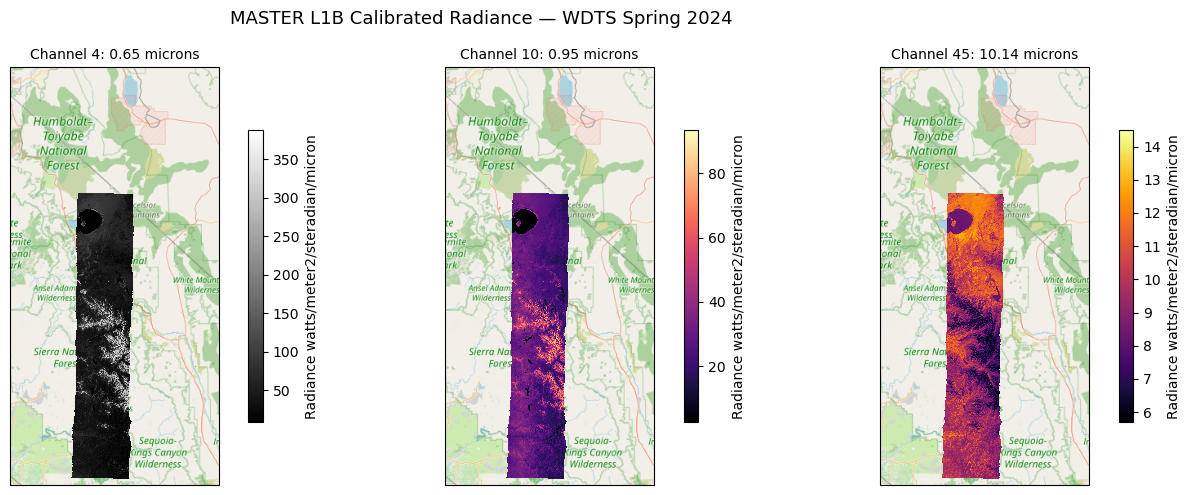

In [13]:
# OpenStreet baselayers
request = cimgt.OSM()
# three columns subplots
fig, axes = plt.subplots(
    nrows=1, ncols=3, figsize=(15, 5), 
    subplot_kw={'projection': request.crs}
)

# channel indices you want to plot
# visible (band 4), NIR (band 10), TIR (band 45)
channels_to_plot = [4, 10, 45]

# corresponding cmaps
cmaps = ['gray', 'magma', 'inferno']

# 3. Loop through your target channels and axes
for ax, ch_idx, cmap in zip(axes, channels_to_plot, cmaps):
    # extract the specific band
    band = ds['radiance'].isel(c=ch_idx)
    # add base layer
    ax.add_image(request, 8)
    # plot one band
    im = band.plot(
        ax=ax, x='lon', y='lat', 
        transform=ccrs.PlateCarree(),
        cmap=cmap, add_colorbar=False 
    )
    
    ax.set_title(f"Channel {ch_idx}: {wv[ch_idx]:.2f} microns", fontsize=10)   
    fig.colorbar(im, ax=ax, label=f"Radiance {units}", pad=0.05, shrink=0.7)

plt.suptitle('MASTER L1B Calibrated Radiance — WDTS Spring 2024', fontsize=13)
plt.tight_layout()
plt.show()